# Introduction

This tutorial is structured into sections and subsections, the legend below presents what each section title corresponds to.

## Tutorial Legend:
* 👾 Setup: Run these code cells to prepare the environment and functions that are being used in the simulations.
* 💡New Concept: Introduction of a concept this tutorial wishes to teach
* 📖 Narrative: Context or insights for this tutorial
* ▶️ Activity: An interactive secion, you will be asked to think, answer questions, or run a simulation
* ⚙️ Simulation: Run a scenario simulation
* ✍️ Write Answer: Fill in the field with your response
* 🧠 Think: You are asked to partake in a thought experiment or reflect on results


# 👾 Setup
Run the cells below and wait, if you are asked to restart the session, do so, and continue with the following cells.

In [1]:
# If running notebook within Google colab, install illuminator and clone educational_material repo to access notebook supporting data
if "google.colab" in str(get_ipython()):
  !pip install Illuminator
  !git clone https://github.com/Illuminator-team/educational_material.git

In [2]:

# If running notebook within Google colab, access the right path of the educational material repo
if "google.colab" in str(get_ipython()):
  import sys
  sys.path.append('/content/educational_material/tutorials/ide_justice_agent_I/')
  %cd /content/educational_material/tutorials/ide_justice_agent_I/

In [3]:
from illuminator.engine import Simulation
import pandas as pd
import nest_asyncio
nest_asyncio.apply()
from illuminator.models.import_custom_model import import_custom_model

# First, import the actual classes from your the functions_T5 file
from functions_T5 import New_House_Type, JusticeAgentController

# Then, register them with your framework to use as custom models
import_custom_model(New_House_Type)
import_custom_model(JusticeAgentController)

# 📖 Narrative

You are setting up a homogenous energy hub. All households in this hub:

* have the same infrastructure
* have the same production capacity
* have the same consumption levels

This is a **uniform** system.

The goal of this hub is to be autonomous, and we approach this by balancing household production and consumption:

* *each household balances its own production and consumption*

* *if every household is balanced, the hub will be balanced*

This introduces a **communitarian justice** logic.

## 💡New Concept

Communitarian justice begins from a different premise than individualist theories.

In the latter, individuals are not understood as isolated and independent units first.

In the former, they are members of a community, and this community shapes their values, responsibilities, and actions.

From a communitarian perspective, *fairness emerges through shared responsibility and participation in maintaining the collective*.

The focus is not primarily on maximizing individual’s benefit, but on sustaining the well-being and cohesion of the community itself.

This means that individuals are expected to respond to collective needs and contribute, within their means, to maintaining the system.

In this logic:

* *fairness is about whether members uphold their a level of responsibility to sustain the collective balance*

* *fairness is about all actors contributing equitably to a meaningful community impact*

***Communitarian Justice***
> Communitarian justice in the context of the energy hub assumes a system is fair when all members contribute to maintaining the collective balance.



# ▶️ Activity 1

To understand how this energy hub behaves, simulation model uses three key indicators to describe the way the energy hub and its households behave:

### 1. Classification of Households:
Each household is classified based on its production ($P_i$) and consumption ($C_i$). This tells us which households depend on collective energy redistribution and which households support it.

* $P_i < C_i \rightarrow$ Hub Receiver: This means that the household consumes more than it produces, therefore part of the demand is met by energy produced by others
* $P_i = C_i \rightarrow$ Balanced Household: This is a household that produces as much as its consumption.
* $P_i > C_i \rightarrow$ Hub Contributor: This household produces more than it consumes, therefore there is a surplus that could be used by others.

### 2. Energy Reciprocity Balance (ERB) Index:
This measures how fairly energy contributions and dependencies are distributed within the hub. Even in a balanced hub, there some households that may contribute more while others may depend more on other’s contributions. The index measures whether the burden of maintaining balance is shared equally across households. It is calculated using a Gini coefficient applied to the difference between household production and consumption.

* $ERB_{Index} = 1 - Gini coefficient(|P_i - C_i|)$
* $Index = 1 \rightarrow$ Perfect reciprocity: Every household contributes and depends equally.
* $Index < 1 \rightarrow$ Unequal reciprocity: Some households contribute more than they depend, while others depend more than they contribute.

### 3. Collective Energy Usage Rate:
This measures if the hub is balanced as a collective or not.

* $= 1 \rightarrow$ Just Enough: The hub is in perfect balance and produces as much as it consumes
* $> 1 \rightarrow$ Deficit: The system lacks energy where the hub consumes more than its local production


* $< 1 \rightarrow$ Surplus: The hub produces more energy than it consumes.

##🧠 Thought Experiment
A key assumption within the communitarianism perspective is that households will align their behaviour to the needs of the community.

In other words, the system **assumes that when imbalance emerges, households will respond in ways that help restore collective balance**.

But does this assumption hold in practice?  

* If all households are identical, will they behave identically?

* If all households are “equal,” will outcomes also be equal?

* If the hub's total energy is in balance, does that mean the system is fair?

* If everyone is asked to act for the collective good, will they?

### ✍️ Write down your assumption below

## ⚙️ Scenario Simulation

The system assumes cooperation. The following simulation model has been designed to test whether that assumption holds.

To test this, we now observe how households respond to the same system conditions over time.

Run the cell below and study the results.

In [4]:
%%capture
CONFIG_FILE = 'data\ide_case_I.yaml'
simulation = Simulation(CONFIG_FILE)
simulation.run()

2026-06-11 14:12:24.578 | INFO     | mosaik.async_scenario:start:508 - Starting 'Justice_Controller-0' (based on starter 'Justice_Controller')
2026-06-11 14:12:24.580 | WARNING  | mosaik.async_scenario:user_warning:360 - c:\Users\dgeorgiadi\AppData\Local\anaconda3\envs\illuminator-examples\Lib\site-packages\mosaik\adapters.py:120: UserWarning: Simulator Justice_Controller-0 is using an outdated API version, namely 1. It should still work. You can suppress this warning by adding an explicit API version for this simulator in your SimConfig.
2026-06-11 14:12:24.582 | INFO     | mosaik.async_scenario:start:508 - Starting 'Neighborhood_A-0' (based on starter 'Neighborhood_A')
2026-06-11 14:12:24.582 | WARNING  | mosaik.async_scenario:user_warning:360 - c:\Users\dgeorgiadi\AppData\Local\anaconda3\envs\illuminator-examples\Lib\site-packages\mosaik\adapters.py:120: UserWarning: Simulator Neighborhood_A-0 is using an outdated API version, namely 1. It should still work. You can suppress this wa

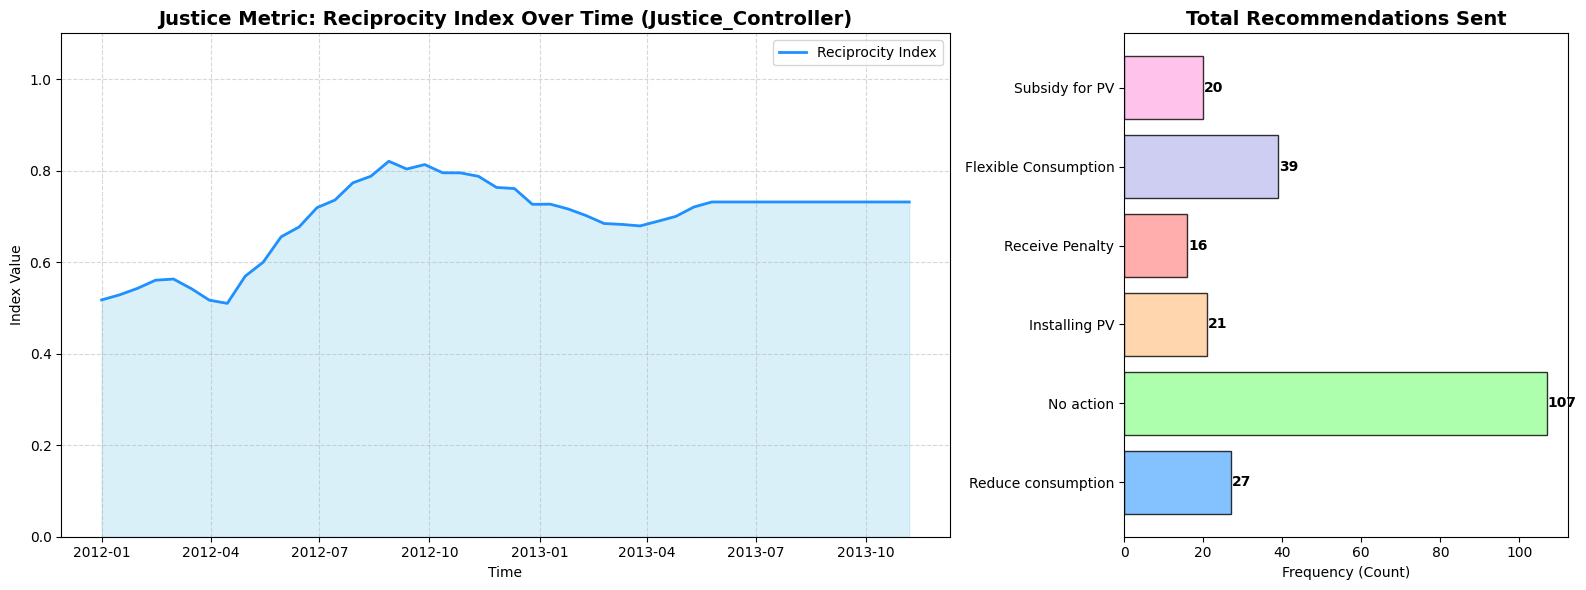


================ JUSTICE SIMULATION SUMMARY ================
Total Individual Recommendations Processed: 230
Action Breakdown:
  - Reduce consumption: 27
  - No action: 107
  - Installing PV: 21
  - Receive Penalty: 16
  - Flexible Consumption: 39
  - Subsidy for PV: 20


In [5]:
from functions_T5 import plot_justice_metrics
plot_justice_metrics('out_justice_test.csv')

## 📖 Narrative:

Even though the hub is structurally uniform, households *do not behave in the same way*. All households receive the same system signal, experience the same deficit, and even have access to the same infrastructure.

Yet over time, different behavioural patterns emerge. Some households respond immediately, some respond partially while some do not respond at all. As a result, some households consistently contribute more energy while others become more dependent on collective redistribution.

This reveals an important tension within communitarian systems: **equal conditions do not necessarily produce equal participation**.

The system assumes that households will act toward a shared collective goal, but in practice individuals interpret and respond to that goal differently.

# 💡New Concept

Communitarian justice explains what the system expects from households. To understand why behaviour diverges, the model uses a simplified behavioural framework inspired by the Beliefs Desires Intentions (BDI) model.

This model helps explain why households may or may not meet those expectations. It is based on the idea that people do not automatically react to external signals. Instead, behaviour emerges through how people interpret a situation, evaluate their priorities and decide whether or not to act.

For our simulation model this translates in:

* **Beliefs**: represent how households understand the state of the system. Beliefs affect whether the system signal is perceived as urgent or important.
For example:

  * Is the energy shortage serious?

  * Does individual action matter?

  * Will other households compensate anyway?

* **Desires**: represent what households value or prioritize. Different households may prioritize comfort, economic savings, environmental responsibility or collective well-being differently. These priorities influence whether households are willing to reduce consumption, increase production or sacrifice personal comfort for collective balance

* **Intentions**: represent the action households ultimately decide to take. Even if two households receive the same signal and value the same things, they may still choose to act differently. Intentions therefore represent how behavioural priorities are translated into actual system response.   



# ▶️ Activity 2

To simulate these behavioural differences, households are assigned personas. Each persona represents a different combination of beliefs, priorities and response tendencies. The personas used in this model are: **📈Market Optimiser**, **🤝Community Steward**, **🌱Green Idealist**, **💤Comfort Prioritiser**

These personas are not meant to represent fixed identities, but behavioural tendencies within the energy system. Each persona is assigned:

* **Weights**: represent how strongly a household values economic, environmental and social or collective outcomes. It reveals what motivates their decision-making. For example:
  
  * a Market Optimiser may prioritize economic benefit

  * a Green Idealist may prioritize environmental goals

  * a Community Steward may prioritize collective balance


* **Thresholds**: But priorities alone do not determine behaviour. Households also differ in how strongly they react and how much change they are willing to accept when they decide to act. In the model, these responses are represented through two thresholds.

  * α =  responsiveness to production incentives  
  * β = responsiveness to consumption incentives
  
  This means that the two households may care about the same issue but one may act immediately (reduce consumption) while another responds weakly (partly reduce consumption) or not at all. So, the behavioural difference emerges not only from values, but from willingness and capacity to respond.

* **Incentives**: The justice agent cannot directly control household behaviour. Instead, the agent attempts to influence decisions through incentives. These incentives may reward contribution, discourage overconsumption and prioritize collective balance

However, incentives do not affect all households equally. Their effectiveness depends on household priorities (weights) and their willingness to respond (thresholds). When an action is recommended to the households, it is attached with social, economic and ecological incentives. These are multiplied by the household weights and if the total is beyond the threshold then the action is taken by the household. Having accepted the action, the degree of response is then governed by the household thresholds.

This means governance in the system is indirect. The justice agent does not force behaviour. Instead, it shapes the conditions under which behavioural change becomes more or less likely.


## ⚙️ Simulation Run

Now that we know this, let’s observe the following:

* Which households consistently overproduce? Which depends on others?

* Who benefits implicitly even in this “equal” system? Who becomes dependent?   

* Does the system become balanced over time? How is that balance achieved?

Run the cells below and study their results.

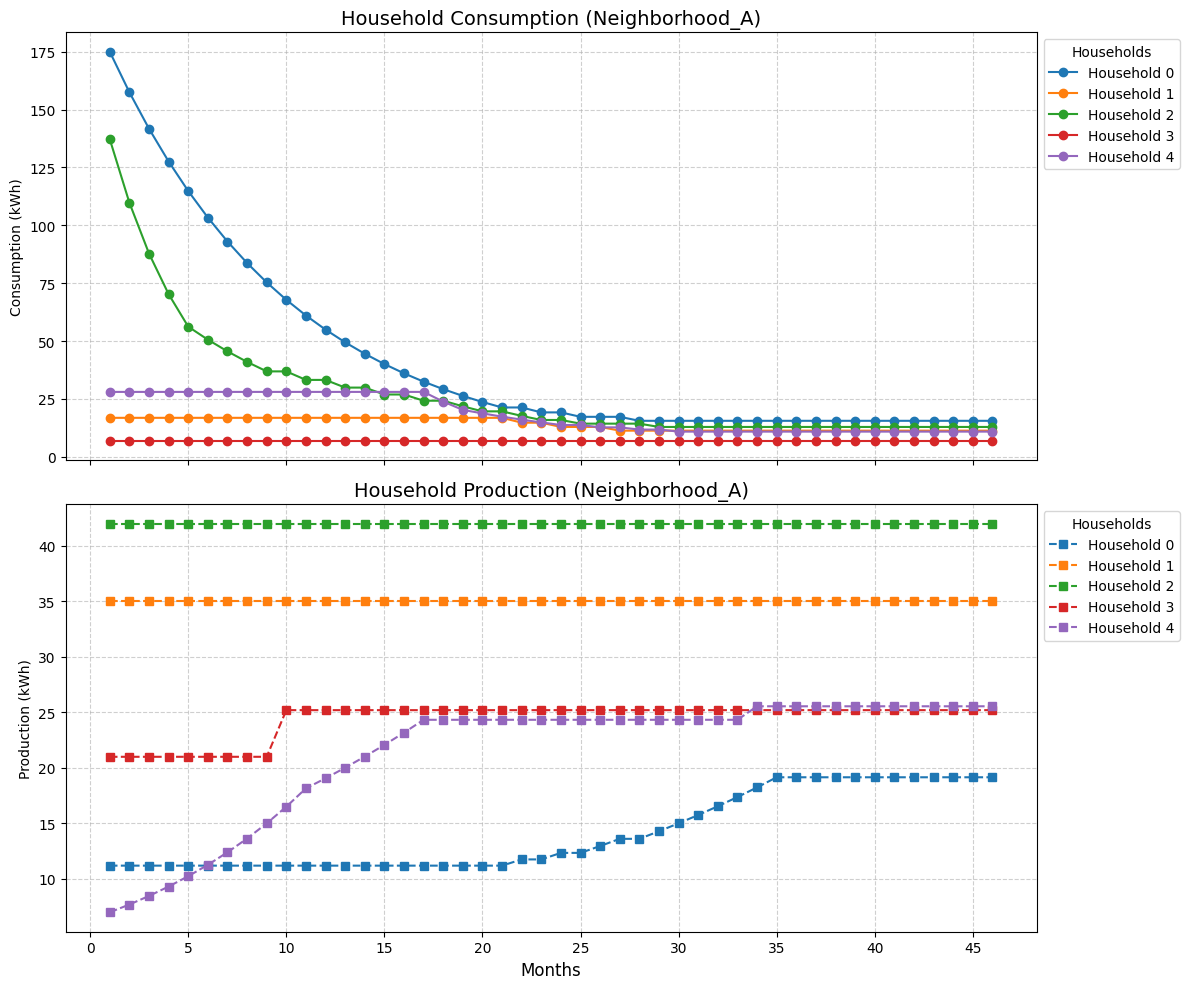

In [6]:
from functions_T5 import plot_neighborhood_energy
plot_neighborhood_energy('out_justice_test.csv')


## Intervention

You can now intervene in the system. Modify either of the following:

* Incentives (e.g., stronger signals, rewards)

* Weights (e.g., prioritizing certain households)

The goal is to encourage the system to become balanced.

Run the model for multiple cycles and observe:

* Does balance improve?

* Who is doing more work to achieve it?  

* Are some households carrying more responsibility for maintaining balance than others?  

Can a communitarian system remain fair if some households consistently carry more responsibility than others?

This creates an important tension: what happens when individuals do not respond equally to collective needs?

In [7]:
%%capture
# Define simulation file
CONFIG_FILE = 'data\ide_case_I.yaml'
simulation = Simulation(CONFIG_FILE)

# Make your changes below! v
new_action_scores = 'xxx' # TODO, do we want this?

# Make your changes below! v
new_incentive_weights = [[0.5, 0.5, 0.8],   #Incentive weights for Household 1
                        [0.5, 0.8, 0.5],    #Incentive weights for Household 2
                        [0.5, 0.5, 0.5],    #Incentive weights for Household 3
                        [0.5, 0.33, 0.5],   #Incentive weights for Household 4
                        [0.5, 0.5, 0.5]]    #Incentive weights for Household 5

# Pass new model parameters to the simulation
simulation.set_model_param('Neighborhood_A', 'incentive_weights', new_incentive_weights)
simulation.run()

2026-06-11 14:12:25.641 | INFO     | mosaik.async_scenario:start:508 - Starting 'Justice_Controller-0' (based on starter 'Justice_Controller')
2026-06-11 14:12:25.643 | WARNING  | mosaik.async_scenario:user_warning:360 - c:\Users\dgeorgiadi\AppData\Local\anaconda3\envs\illuminator-examples\Lib\site-packages\mosaik\adapters.py:120: UserWarning: Simulator Justice_Controller-0 is using an outdated API version, namely 1. It should still work. You can suppress this warning by adding an explicit API version for this simulator in your SimConfig.
2026-06-11 14:12:25.644 | INFO     | mosaik.async_scenario:start:508 - Starting 'Neighborhood_A-0' (based on starter 'Neighborhood_A')
2026-06-11 14:12:25.646 | WARNING  | mosaik.async_scenario:user_warning:360 - c:\Users\dgeorgiadi\AppData\Local\anaconda3\envs\illuminator-examples\Lib\site-packages\mosaik\adapters.py:120: UserWarning: Simulator Neighborhood_A-0 is using an outdated API version, namely 1. It should still work. You can suppress this wa

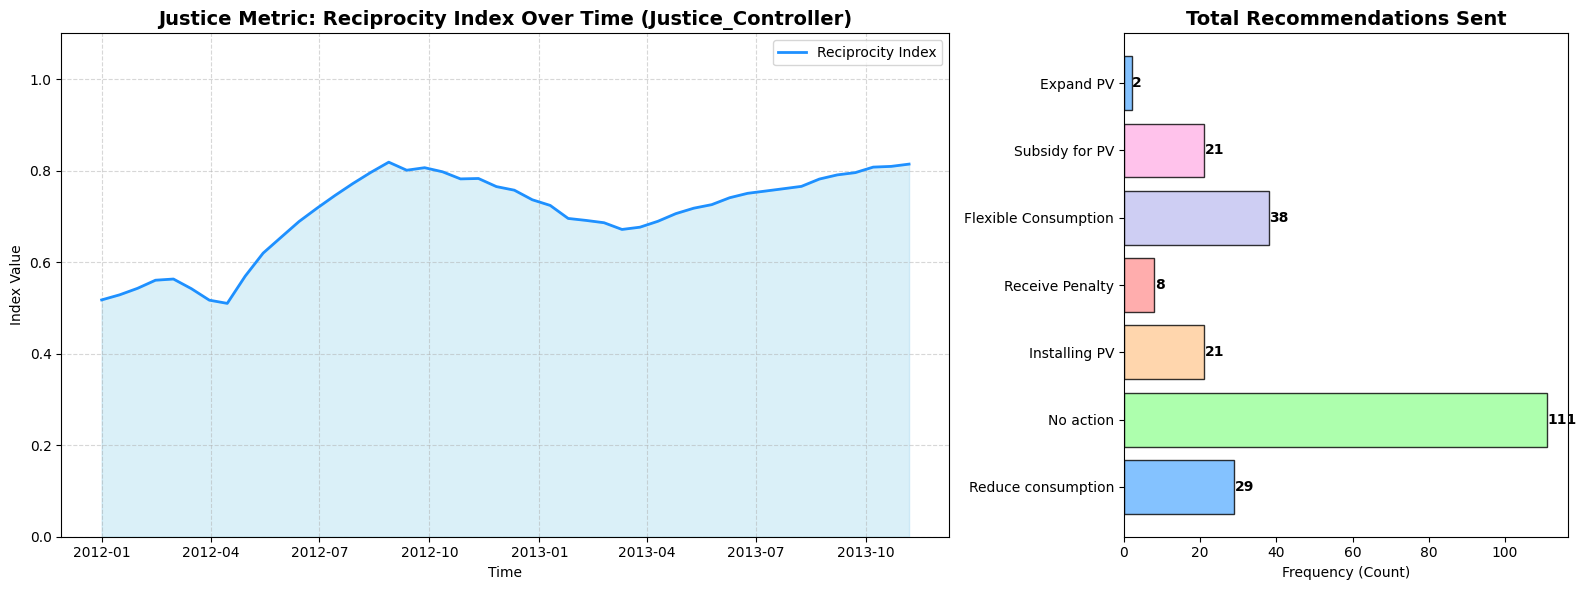


================ JUSTICE SIMULATION SUMMARY ================
Total Individual Recommendations Processed: 230
Action Breakdown:
  - Reduce consumption: 29
  - No action: 111
  - Installing PV: 21
  - Receive Penalty: 8
  - Flexible Consumption: 38
  - Subsidy for PV: 21
  - Expand PV: 2


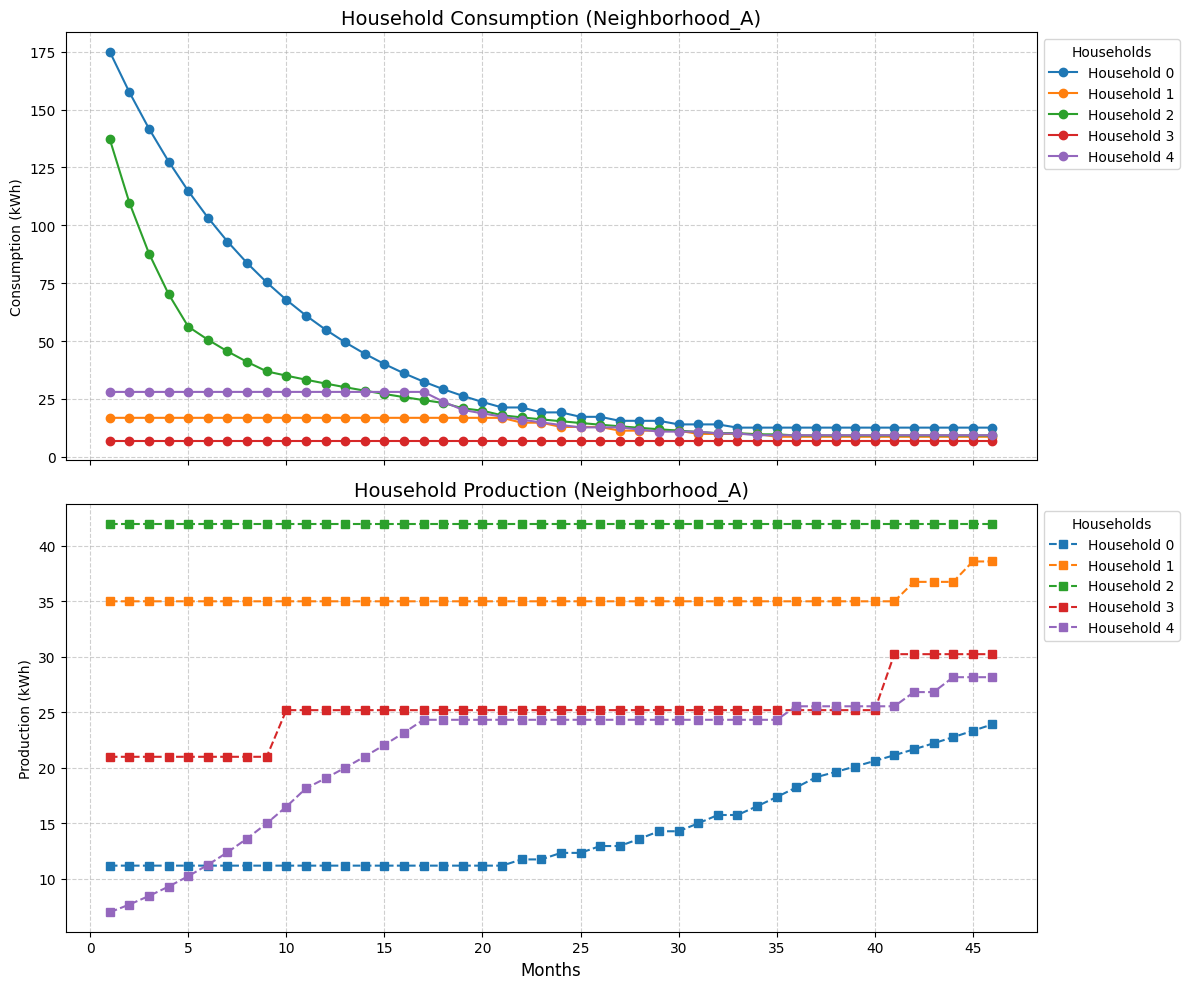

In [8]:
plot_justice_metrics('out_justice_test.csv')
plot_neighborhood_energy('out_justice_test.csv')

# 🧠 Reflection

The model is now balanced. Before we move on, there are some crucial things to consider. This model assumes:

* Everyone has the same capacity

* Everyone can respond when needed

* Balance is the primary goal

* There is no scarcity pressure, no structural inequality and no power imbalance

This is a **controlled abstraction**.



But consider:

* Are needs and wants treated the same?  

* Does this system actually guarantee basic needs?

* Does balancing the system ensure that everyone has *enough*?

* Is this system optimized for ecological balance and “just” to the environment?

* What does it mean for a system to provide enough for everyone?  

* What happens when “balance” is not the same as “sufficiency”?  